# Peer Comparison Case Study

This case study applies relative valuation to a Nestle-like company and a synthetic peer group. The goal is to learn the workflow, not to produce a real-time investment recommendation.

Abbreviations used in this notebook:

- **P/E**: Price to Earnings, share price divided by earnings per share.
- **EPS**: Earnings Per Share, net income divided by shares outstanding.
- **EV**: Enterprise Value, equity value plus net debt.
- **EBITDA**: Earnings Before Interest, Taxes, Depreciation, and Amortization.
- **EBIT**: Earnings Before Interest and Taxes.
- **P/S**: Price to Sales, market capitalization divided by revenue.
- **P/B**: Price to Book, market capitalization divided by book equity.
- **CHF**: Swiss franc, the currency used in the examples.

## 1. Intuition

A peer comparison asks whether a company is cheap or expensive relative to similar companies. It does not prove intrinsic value, but it provides a market-based cross-check against a DCF.

A good peer comparison needs three things:

- Comparable companies with similar economics.
- Clean, consistently calculated multiples.
- Judgment about whether the target deserves a premium or discount.

For a mature consumer staples company, the most useful multiples are often P/E, EV/EBITDA, EV/EBIT, P/S, and P/B.

## 2. Mathematics

Enterprise value:

$$
EV = \text{Market Cap} + \text{Net Debt}
$$

P/E multiple:

$$
P/E = \frac{\text{Market Cap}}{\text{Net Income}}
$$

EV/EBITDA multiple:

$$
EV/EBITDA = \frac{EV}{EBITDA}
$$

Premium or discount to peers:

$$
\text{Premium / Discount} = \frac{\text{Target Multiple}}{\text{Peer Median Multiple}} - 1
$$

Implied equity value from an EV multiple:

$$
\text{Equity Value} = (\text{Target Metric} \times \text{Peer Multiple}) - \text{Net Debt}
$$

## 3. Implementation

We will create a synthetic peer set, calculate multiples, compare the target with peer medians, and estimate implied share prices.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

companies = pd.DataFrame({
    "company": ["Nestle-like Target", "Global Food A", "Beverage B", "Household C", "Nutrition D", "Packaged Food E"],
    "revenue": [102_000, 88_000, 74_000, 69_000, 52_000, 44_000],
    "ebitda": [22_400, 19_200, 17_400, 14_300, 11_100, 8_700],
    "ebit": [17_500, 14_900, 13_600, 11_000, 8_400, 6_300],
    "net_income": [12_100, 10_200, 9_300, 7_800, 5_700, 4_100],
    "book_equity": [68_600, 58_000, 47_000, 43_000, 31_000, 25_000],
    "market_cap": [255_000, 206_000, 198_000, 151_000, 106_000, 75_000],
    "net_debt": [35_000, 30_000, 24_000, 19_000, 12_000, 9_000],
    "shares_outstanding": [2_650, 1_850, 1_420, 1_180, 880, 720],
    "expected_growth": [0.055, 0.050, 0.060, 0.045, 0.052, 0.034],
    "ebit_margin": [0.172, 0.169, 0.184, 0.159, 0.162, 0.143],
})

companies["enterprise_value"] = companies["market_cap"] + companies["net_debt"]
companies["share_price"] = companies["market_cap"] / companies["shares_outstanding"]
companies["eps"] = companies["net_income"] / companies["shares_outstanding"]
companies["pe"] = companies["market_cap"] / companies["net_income"]
companies["ev_ebitda"] = companies["enterprise_value"] / companies["ebitda"]
companies["ev_ebit"] = companies["enterprise_value"] / companies["ebit"]
companies["price_sales"] = companies["market_cap"] / companies["revenue"]
companies["price_book"] = companies["market_cap"] / companies["book_equity"]

companies.round(2)

,company,revenue,ebitda,ebit,net_income,book_equity,market_cap,net_debt,shares_outstanding,expected_growth,ebit_margin,enterprise_value,share_price,eps,pe,ev_ebitda,ev_ebit,price_sales,price_book
0,Nestle-like Target,102000,22400,17500,12100,68600,255000,35000,2650,0.06,0.17,290000,96.23,4.57,21.07,12.95,16.57,2.50,3.72
1,Global Food A,88000,19200,14900,10200,58000,206000,30000,1850,0.05,0.17,236000,111.35,5.51,20.20,12.29,15.84,2.34,3.55
2,Beverage B,74000,17400,13600,9300,47000,198000,24000,1420,0.06,0.18,222000,139.44,6.55,21.29,12.76,16.32,2.68,4.21
3,Household C,69000,14300,11000,7800,43000,151000,19000,1180,0.04,0.16,170000,127.97,6.61,19.36,11.89,15.45,2.19,3.51
4,Nutrition D,52000,11100,8400,5700,31000,106000,12000,880,0.05,0.16,118000,120.45,6.48,18.60,10.63,14.05,2.04,3.42
5,Packaged Food E,44000,8700,6300,4100,25000,75000,9000,720,0.03,0.14,84000,104.17,5.69,18.29,9.66,13.33,1.70,3.00


In [2]:
target = companies.iloc[0]
peers = companies.iloc[1:].copy()
multiple_columns = ["pe", "ev_ebitda", "ev_ebit", "price_sales", "price_book"]

peer_stats = peers[multiple_columns].agg(["min", "median", "max"]).T
peer_stats["target"] = target[multiple_columns]
peer_stats["target_vs_peer_median"] = peer_stats["target"] / peer_stats["median"] - 1
peer_stats.round(2)

,min,median,max,target,target_vs_peer_median
pe,18.29,19.36,21.29,21.07438,0.08861
ev_ebitda,9.66,11.89,12.76,12.946429,0.089023
ev_ebit,13.33,15.45,16.32,16.571429,0.072269
price_sales,1.70,2.19,2.68,2.5,0.142384
price_book,3.00,3.51,4.21,3.717201,0.058541


In [3]:
def implied_price(metric, multiple, net_debt=0, shares_outstanding=1, enterprise_multiple=False):
    if enterprise_multiple:
        equity_value = metric * multiple - net_debt
    else:
        equity_value = metric * multiple
    return equity_value / shares_outstanding

implied_prices = pd.Series({
    "P/E median": implied_price(target["net_income"], peer_stats.loc["pe", "median"], shares_outstanding=target["shares_outstanding"]),
    "EV/EBITDA median": implied_price(target["ebitda"], peer_stats.loc["ev_ebitda", "median"], net_debt=target["net_debt"], shares_outstanding=target["shares_outstanding"], enterprise_multiple=True),
    "EV/EBIT median": implied_price(target["ebit"], peer_stats.loc["ev_ebit", "median"], net_debt=target["net_debt"], shares_outstanding=target["shares_outstanding"], enterprise_multiple=True),
    "P/S median": implied_price(target["revenue"], peer_stats.loc["price_sales", "median"], shares_outstanding=target["shares_outstanding"]),
    "P/B median": implied_price(target["book_equity"], peer_stats.loc["price_book", "median"], shares_outstanding=target["shares_outstanding"]),
})

implied_prices.to_frame("implied_price_chf").round(2)

,implied_price_chf
P/E median,88.39
EV/EBITDA median,87.28
EV/EBIT median,88.85
P/S median,84.23
P/B median,90.90


## 4. Visualization

Peer charts make relative valuation easier to inspect. The target should be visible against the rest of the peer set.

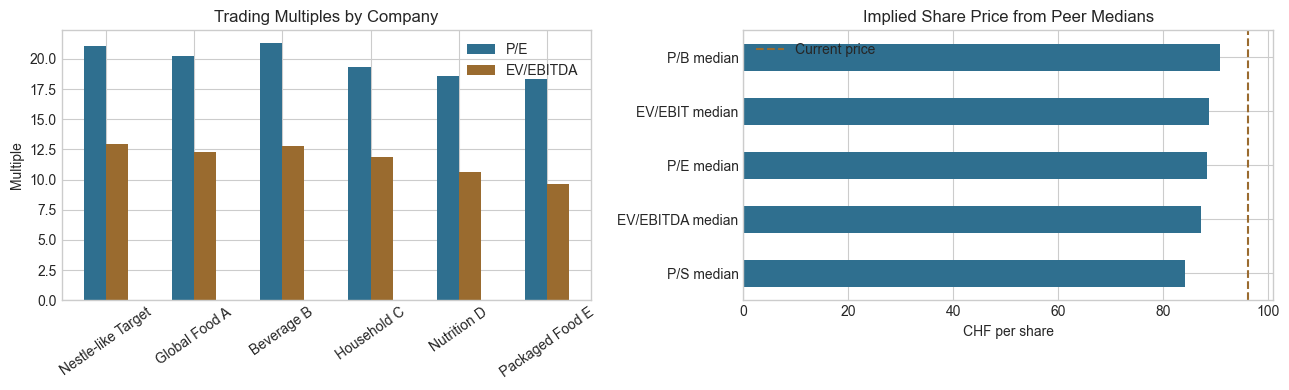

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

companies.set_index("company")[["pe", "ev_ebitda"]].plot(kind="bar", ax=axes[0], color=["#2f6f8f", "#9a6b2f"])
axes[0].set_title("Trading Multiples by Company")
axes[0].set_xlabel("")
axes[0].set_ylabel("Multiple")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(["P/E", "EV/EBITDA"])

implied_prices.sort_values().plot(kind="barh", ax=axes[1], color="#2f6f8f")
axes[1].axvline(target["share_price"], color="#9a6b2f", linestyle="--", label="Current price")
axes[1].set_title("Implied Share Price from Peer Medians")
axes[1].set_xlabel("CHF per share")
axes[1].legend()

plt.tight_layout()
plt.show()

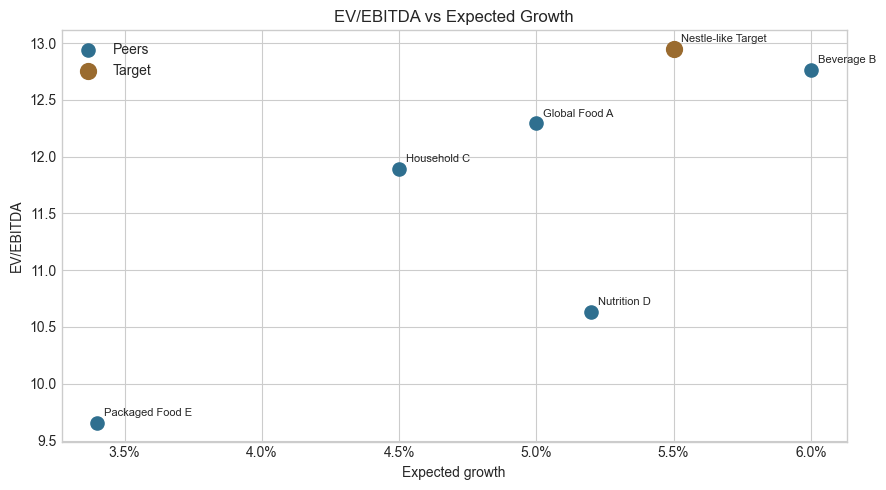

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(peers["expected_growth"], peers["ev_ebitda"], s=90, color="#2f6f8f", label="Peers")
ax.scatter(target["expected_growth"], target["ev_ebitda"], s=130, color="#9a6b2f", label="Target")

for _, row in companies.iterrows():
    ax.annotate(row["company"], (row["expected_growth"], row["ev_ebitda"]), xytext=(5, 5), textcoords="offset points", fontsize=8)

ax.set_title("EV/EBITDA vs Expected Growth")
ax.set_xlabel("Expected growth")
ax.set_ylabel("EV/EBITDA")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Application

A peer comparison should end with judgment, not just a table. A premium can be justified if the target has stronger brands, better margins, lower risk, cleaner accounting, or more resilient growth. A discount can be justified if growth is slower, leverage is higher, margins are weaker, or the business mix is less attractive.

This case is most useful when compared with the Nestle DCF case study. If both approaches point to a similar valuation range, confidence increases. If they disagree, the next task is to understand why.

In [6]:
current_price = target["share_price"]
median_implied_price = implied_prices.median()
upside_downside = median_implied_price / current_price - 1

print(f"Current target price: CHF {current_price:,.2f}")
print(f"Median peer-implied price: CHF {median_implied_price:,.2f}")
print(f"Implied upside/downside: {upside_downside:.1%}")
print(f"Peer-implied range: CHF {implied_prices.min():,.2f} to CHF {implied_prices.max():,.2f}")

Current target price: CHF 96.23
Median peer-implied price: CHF 88.39
Implied upside/downside: -8.1%
Peer-implied range: CHF 84.23 to CHF 90.90


## 6. Reflection

- Relative valuation is fast and market-aware, but peer selection is subjective.
- Enterprise value multiples are useful when companies have different leverage.
- P/E is intuitive, but it can be distorted by one-off earnings and capital structure.
- Growth and margins help explain why one company deserves a higher or lower multiple.
- Peer comparison is strongest when used alongside a DCF case study.

Questions to answer after running the notebook:

1. Does the target trade at a premium or discount to the peer median?
2. Which multiple gives the most conservative implied price?
3. Which company would you remove from the peer set, and why?
4. Does the peer comparison support or challenge the DCF case?